In [1]:
# keep all discharge dummy

In [2]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report

In [3]:
import warnings
warnings.filterwarnings("ignore")

#### data processing

In [4]:
data_path = "../data/"
output_path = "../output/"

In [5]:
data = pd.read_csv(data_path + "diabetes_130_full.csv", low_memory = False)

##### mapping

In [6]:
### Assign relevant item mapping to id from csv

IDs_mapping = pd.read_csv(data_path + "IDS_mapping.csv")

admission_id_mapping = IDs_mapping.iloc[:8, :]
admission_id_mapping['admission_type_id'] = admission_id_mapping['admission_type_id'].astype(int)
admission_id_mapping = admission_id_mapping.set_index('admission_type_id')['description'].to_dict()

discharge_id_mapping = IDs_mapping.iloc[10:40, :]
discharge_id_mapping['admission_type_id'] = discharge_id_mapping['admission_type_id'].astype(int)
discharge_id_mapping = discharge_id_mapping.set_index('admission_type_id')['description'].to_dict()

admission_source_id_mapping = IDs_mapping.iloc[42:, :]
admission_source_id_mapping['admission_type_id'] = admission_source_id_mapping['admission_type_id'].astype(int)
admission_source_id_mapping = admission_source_id_mapping.set_index('admission_type_id')['description'].to_dict()

data['admission_type_id'] = data['admission_type_id'].map(admission_id_mapping)
data['discharge_disposition_id'] = data['discharge_disposition_id'].map(discharge_id_mapping)
data['admission_source_id'] = data['admission_source_id'].map(admission_source_id_mapping)

In [7]:
def map_diag_category(code):
    """
    Map ICD-9 diagnosis codes to broad disease categories.
    Returns 'Unknown' for missing or unrecognized codes.
    Based on wikipedia: https://en.wikipedia.org/wiki/List_of_ICD-9_codes
    """
    if pd.isna(code):
        return "Other / Unknown"

    # Try converting to float if it's numeric
    try:
        code = float(str(code).split('.')[0])
    except:
        return "Other / Unknown"

    # Now safe to compare numerically
    if 1 <= code <= 139:
        return 'Infectious & Parasitic'
    elif 140 <= code <= 239:
        return 'Neoplasms'
    elif 249 <= code < 251:
        return "Diabetes mellitus"
    elif 240 <= code <= 279:
        return 'Endocrine / Metabolic / Immunity'
    elif 280 <= code <= 289:
        return 'Blood & Blood-forming Organs'
    elif 290 <= code <= 319:
        return 'Mental Disorders'
    elif 320 <= code <= 389:
        return 'Nervous System'
    elif 390 <= code <= 459:
        return 'Circulatory System'
    elif 460 <= code <= 519:
        return 'Respiratory System'
    elif 520 <= code <= 579:
        return 'Digestive System'
    elif 580 <= code <= 629:
        return 'Genitourinary System'
    elif 630 <= code <= 679:
        return 'Pregnancy / Childbirth'
    elif 680 <= code <= 709:
        return 'Skin & Subcutaneous Tissue'
    elif 710 <= code <= 739:
        return 'Musculoskeletal System'
    elif 740 <= code <= 759:
        return 'Congenital Anomalies'
    elif 760 <= code <= 779:
        return 'Perinatal Conditions'
    elif 780 <= code <= 799:
        return 'Symptoms / Ill-defined Conditions'
    elif 800 <= code <= 999:
        return 'Injury & Poisoning'
    else:
        return 'Other / Unknown'

# Apply mapping to diagnosis columns
data['diag_1_category'] = data['diag_1'].apply(map_diag_category)

In [8]:
# Fill NaN and ensure lowercase strings
data['discharge_disposition_category'] = (
    data['discharge_disposition_id']
    .fillna('unknown')
    .astype(str)
    .str.lower()
)

conditions = [
    data['discharge_disposition_id'].str.lower().str.contains('hospice', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('home', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('outpatient|still patient', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('ama|admitted|inpatient', na=False),
    data['discharge_disposition_id'].str.lower().str.contains('hospital|rehab|swing bed|snf|icf|nursing|psychiatric|federal', na=False),
]

choices = [
    'hospice',
    'home',
    'outpatient',
    'inpatient',
    'hospital / facility'
]

data['discharge_disposition_category'] = np.select(conditions, choices, default='other')

print(data['discharge_disposition_category'].value_counts())

discharge_disposition_category
home                   73244
hospital / facility    19563
other                   6322
inpatient               1828
hospice                  781
outpatient                28
Name: count, dtype: int64


##### Feature engineering

In [9]:
#Total procedures
data['total_procedures'] = (
    data['num_lab_procedures'] + data['num_procedures'] + data['num_medications']
)

#Ratio features
data['lab_med_ratio'] = data['num_lab_procedures'] / (data['num_medications'] + 1)

In [10]:
data.drop(columns = ['Unnamed: 0'], axis = 1, inplace = True)

In [11]:
## drop repeated encounters, only keep the first. 

data.sort_values(by = ['encounter_id'], inplace = True)
data = data.drop_duplicates(subset='patient_nbr', keep='first')      

In [12]:
data = data[data['gender'].isin(['Female', 'Male'])]  # drop 3 rows, small missing

In [13]:
data = data[~data['discharge_disposition_id'].str.lower().str.contains('expired', na=False)]  # patient who are expired, unable to get readmission according to the data.

In [14]:
data['insulin'] = data['insulin'].replace({'Up': 'Change', 'Down': 'Change'})

In [15]:
data.shape

(70431, 54)

### Features Removal

##### Remove features with 75% missing, unless the missing refer to 'Not Taken' such as Test Results

In [16]:
# Missing Analysis (% Missing)

missing_results = data.isnull().sum() / len(data)

print("\nVariables with any missing values (descending)")
missing_results[missing_results > 0.75].sort_values(ascending = False)


Variables with any missing values (descending)


weight           0.960046
max_glu_serum    0.951939
A1Cresult        0.817154
dtype: float64

In [17]:
data.drop(columns = ['weight'], axis = 1, inplace = True)

We will keep the <strong>max_glu_serum</strong> and <strong>A1Cresult</strong> as these are test results -- missing just refer to patients who did not take the test. <br>This itself carry valuable information in the context of diabetic readmission

##### Remove features with no inherent relationship to diabetic readmission

In [18]:
data.drop(columns = ['admission_source_id', 
                     'payer_code', 
                     'medical_specialty',
                     'encounter_id', 
                     'patient_nbr'], axis = 1, inplace = True)

##### Remove features with low cardinality (i.e., >= 95% same value)

In [19]:
threshold = 0.95  # 95%

unique_ratio = data.nunique() / len(data)
dominant_ratio = data.apply(lambda col: col.value_counts(normalize=True).iloc[0])
low_variance_cols = dominant_ratio[dominant_ratio >= threshold].index.tolist()
print("Low-variance columns (≥95% same value):")
print(low_variance_cols)

Low-variance columns (≥95% same value):
['repaglinide', 'nateglinide', 'chlorpropamide', 'acetohexamide', 'tolbutamide', 'acarbose', 'miglitol', 'troglitazone', 'tolazamide', 'examide', 'citoglipton', 'glyburide-metformin', 'glipizide-metformin', 'glimepiride-pioglitazone', 'metformin-rosiglitazone', 'metformin-pioglitazone']


In [20]:
data.drop(columns = low_variance_cols, axis = 1, inplace = True)

In [21]:
mapping = {'NO': 0, '>30': 0, '<30': 1}
data['readmitted_binary'] = data['readmitted'].map(mapping)   # predicting short term readmission risk

In [22]:
data.drop(columns = ['readmitted'], axis = 1, inplace = True)

In [23]:
data = data.fillna("None")

In [24]:
data.shape

(70431, 32)

#### start

In [25]:
X = data.iloc[:, :-1]
y = data.iloc[:, -1]

In [26]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.3, random_state=42, stratify=y
)

In [27]:
X_train

,race,gender,age,admission_type_id,discharge_disposition_id,time_in_hospital,num_lab_procedures,num_procedures,num_medications,number_outpatient,...,glyburide,pioglitazone,rosiglitazone,insulin,change,diabetesMed,diag_1_category,discharge_disposition_category,total_procedures,lab_med_ratio
15796,Caucasian,Female,[70-80),Emergency,None,2,46,0,10,0,...,No,No,Steady,No,No,Yes,Circulatory System,other,56,4.181818
91253,Hispanic,Female,[30-40),Emergency,Discharged to home,2,57,0,4,0,...,No,No,No,Steady,Ch,Yes,Diabetes mellitus,home,61,11.400000
3377,Caucasian,Female,[70-80),Emergency,Discharged/transferred to SNF,5,62,0,16,0,...,No,No,No,Change,Ch,Yes,Respiratory System,hospital / facility,78,3.647059
16822,Caucasian,Female,[60-70),Elective,None,9,51,6,53,0,...,Steady,No,No,No,No,Yes,Circulatory System,other,110,0.944444
57752,Caucasian,Male,[60-70),Elective,Discharged/transferred to home with home healt...,3,28,3,30,0,...,Steady,No,Steady,No,Ch,Yes,Musculoskeletal System,home,61,0.903226
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
819,Caucasian,Female,[40-50),Elective,Discharged to home,2,34,2,18,0,...,No,No,No,Change,Ch,Yes,Injury & Poisoning,home,54,1.789474
31852,None,Male,[40-50),Urgent,Discharged to home,5,64,1,11,0,...,No,No,No,Steady,No,Yes,Diabetes mellitus,home,76,5.333333
92538,Caucasian,Female,[60-70),Urgent,Discharged/transferred to home with home healt...,10,59,2,44,0,...,No,No,No,Change,Ch,Yes,Digestive System,home,105,1.311111
45895,AfricanAmerican,Female,[70-80),Elective,Discharged to home,1,28,2,11,1,...,No,No,No,No,No,Yes,Circulatory System,home,41,2.333333


### Single Factor Analysis (WoE and IV) only on the Train to avoid Data Leakage

##### Categorical Variables

In [28]:
Categorical_var = X_train.select_dtypes(include='object').columns.tolist()
Categorical_var = [col for col in Categorical_var if col != 'readmitted']
print("Categorical columns:\n")
print(Categorical_var)

Categorical columns:

['race', 'gender', 'age', 'admission_type_id', 'discharge_disposition_id', 'diag_1', 'diag_2', 'diag_3', 'max_glu_serum', 'A1Cresult', 'metformin', 'glimepiride', 'glipizide', 'glyburide', 'pioglitazone', 'rosiglitazone', 'insulin', 'change', 'diabetesMed', 'diag_1_category', 'discharge_disposition_category']


In [29]:
def woe_discrete(X, y, categorical_var):
    # Combine X and y temporarily inside the function
    df = X.copy()
    df['Bad'] = y.values  # y must be aligned index-wise with X

    WoE_results = pd.DataFrame()
    WoE_results[categorical_var] = df[categorical_var].astype(str).fillna('Missing')
    WoE_results['Bad'] = df['Bad']

    # Count and mean (bad rate)
    Count = WoE_results.groupby(categorical_var).count().reset_index()
    Mean = WoE_results.groupby(categorical_var).mean().reset_index()

    result = pd.concat([Count, Mean], axis=1).iloc[:, [0, 1, 3]]
    result.columns = [categorical_var, 'n_obs', 'prop_bad']

    # Compute stats
    result['prop_good'] = 1 - result['prop_bad']
    result['n_bad'] = result['prop_bad'] * result['n_obs']
    result['n_good'] = result['prop_good'] * result['n_obs']
    result['prop_n_bad'] = result['n_bad'] / result['n_bad'].sum()
    result['prop_n_good'] = result['n_good'] / result['n_good'].sum()

    # WoE & IV
    result['WoE'] = np.log((result['prop_n_good'] + 1e-10) / (result['prop_n_bad'] + 1e-10))
    result['%Good - %Bad'] = result['prop_n_good'] - result['prop_n_bad']
    result['IV'] = result['WoE'] * result['%Good - %Bad']
    result['IV'] = result['IV'].sum()
    result['prop_total'] = result['n_obs'] / result['n_obs'].sum()

    # Sort bins (numerically if possible)
    try:
        result[categorical_var] = result[categorical_var].astype(float)
        result.sort_values(by=categorical_var, inplace=True)
    except ValueError:
        result.sort_values(by=categorical_var, inplace=True)

    result.reset_index(drop=True, inplace=True)
    return result

In [30]:
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()                               

def plot_by_woe(df, rotation_of_x_axis_labels = 0):
    x = np.array(df.iloc[:, 0].apply(str))            
    y = df['WoE']
    plt.figure(figsize=(18, 6))
    plt.plot(x, y, marker = 'o', linestyle = '--', color = 'k')
    plt.xlabel(df.columns[0])
    plt.ylabel('Weight of Evidence')
    plt.title(str('Weight of Evidence by ' + df.columns[0]))
    plt.xticks(rotation = rotation_of_x_axis_labels)

In [31]:
iv_dict = {}

for var in Categorical_var:
    result_df = woe_discrete(X_train, y_train, var)
    iv_value = result_df['IV'].iloc[0] 
    iv_dict[var] = iv_value

iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))

for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

diag_1: 0.7425
diag_3: 0.6386
diag_2: 0.6208
discharge_disposition_id: 0.1846
discharge_disposition_category: 0.1180
age: 0.0296
diag_1_category: 0.0289
diabetesMed: 0.0167
insulin: 0.0110
admission_type_id: 0.0080
race: 0.0044
change: 0.0038
glipizide: 0.0030
max_glu_serum: 0.0014
metformin: 0.0013
glimepiride: 0.0009
rosiglitazone: 0.0007
pioglitazone: 0.0006
A1Cresult: 0.0006
glyburide: 0.0004
gender: 0.0003


In [32]:
#### keep age (ordinal), 
#### discharge_disposition_id_category, diag_1_category (categorical)

### Ordinal Categorical

### Age

In [33]:
woe_discrete(X_train, y_train, 'age')

,age,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,[0-10),99,0.030303,0.969697,3.0,96.0,0.000681,0.002138,1.144127,0.001457,0.029559,0.002008
1,[10-20),381,0.052493,0.947507,20.0,361.0,0.004540,0.008041,0.571537,0.003501,0.029559,0.007728
2,[20-30),803,0.069738,0.930262,56.0,747.0,0.012713,0.016638,0.269105,0.003926,0.029559,0.016288
3,[30-40),1873,0.069407,0.930593,130.0,1743.0,0.029512,0.038823,0.274220,0.009311,0.029559,0.037991
4,[40-50),4821,0.075296,0.924704,363.0,4458.0,0.082406,0.099296,0.186444,0.016890,0.029559,0.097787
5,[50-60),8576,0.072994,0.927006,626.0,7950.0,0.142111,0.177076,0.219968,0.034965,0.029559,0.173952
6,[60-70),11072,0.088602,0.911398,981.0,10091.0,0.222701,0.224764,0.009218,0.002062,0.029559,0.224580
7,[70-80),12469,0.102494,0.897506,1278.0,11191.0,0.290125,0.249265,-0.151795,-0.040860,0.029559,0.252916
8,[80-90),7960,0.104397,0.895603,831.0,7129.0,0.188649,0.158789,-0.172312,-0.029860,0.029559,0.161457
9,[90-100),1247,0.093825,0.906175,117.0,1130.0,0.026561,0.025169,-0.053809,-0.001391,0.029559,0.025294


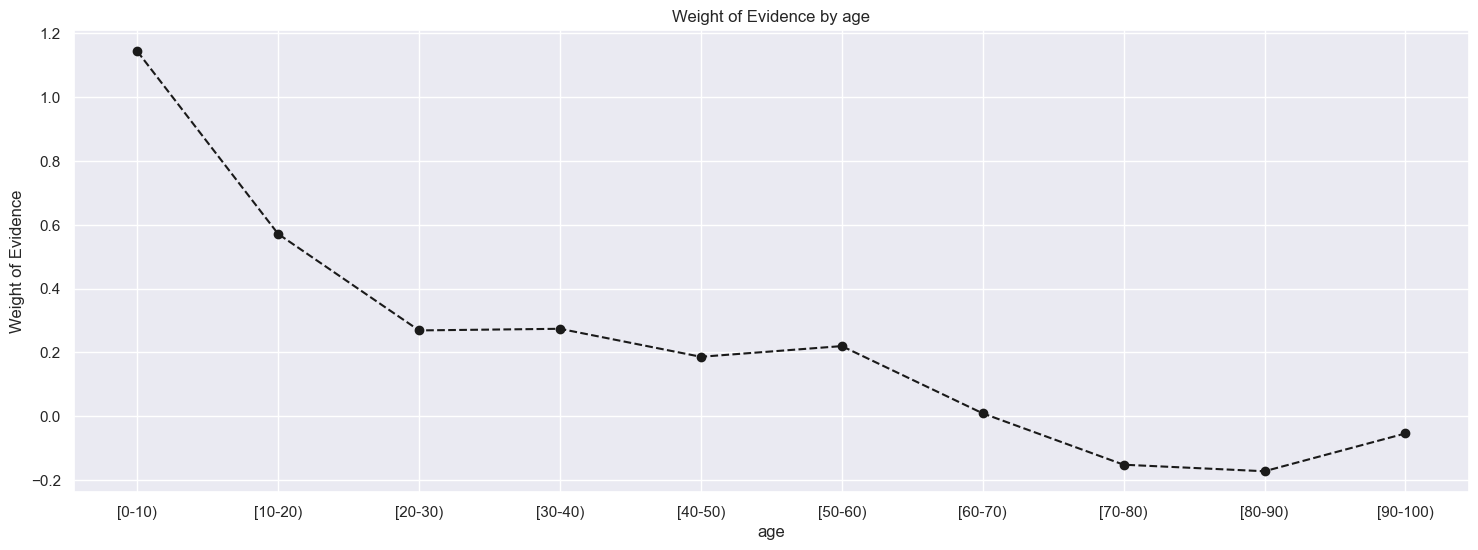

In [34]:
plot_by_woe(woe_discrete(X_train, y_train, 'age'))

In [35]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_train['age_encoded'] = X_train['age'].map(age_mapping)
print(X_train[['age', 'age_encoded']])        

           age  age_encoded
15796  [70-80)            8
91253  [30-40)            4
3377   [70-80)            8
16822  [60-70)            7
57752  [60-70)            7
...        ...          ...
819    [40-50)            5
31852  [40-50)            5
92538  [60-70)            7
45895  [70-80)            8
60652  [60-70)            7

[49301 rows x 2 columns]


## Nominal Categorical

### Discharge disposition

In [36]:
woe_discrete(X_train, y_train, 'discharge_disposition_category').sort_values(by = ['prop_bad'], ascending = False)

,discharge_disposition_category,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
3,inpatient,942,0.158174,0.841826,149.0,793.0,0.033825,0.017663,-0.649732,-0.016162,0.118042,0.019107
2,hospital / facility,8970,0.147046,0.852954,1319.0,7651.0,0.299432,0.170416,-0.563646,-0.129016,0.118042,0.181944
4,other,2286,0.093176,0.906824,213.0,2073.0,0.048354,0.046173,-0.046148,-0.002181,0.118042,0.046368
5,outpatient,11,0.090909,0.909091,1.0,10.0,0.000227,0.000223,-0.019023,-0.000004,0.118042,0.000223
0,home,36778,0.073767,0.926233,2713.0,34065.0,0.615891,0.758754,0.208607,0.142863,0.118042,0.745989
1,hospice,314,0.031847,0.968153,10.0,304.0,0.002270,0.006771,1.092834,0.004501,0.118042,0.006369


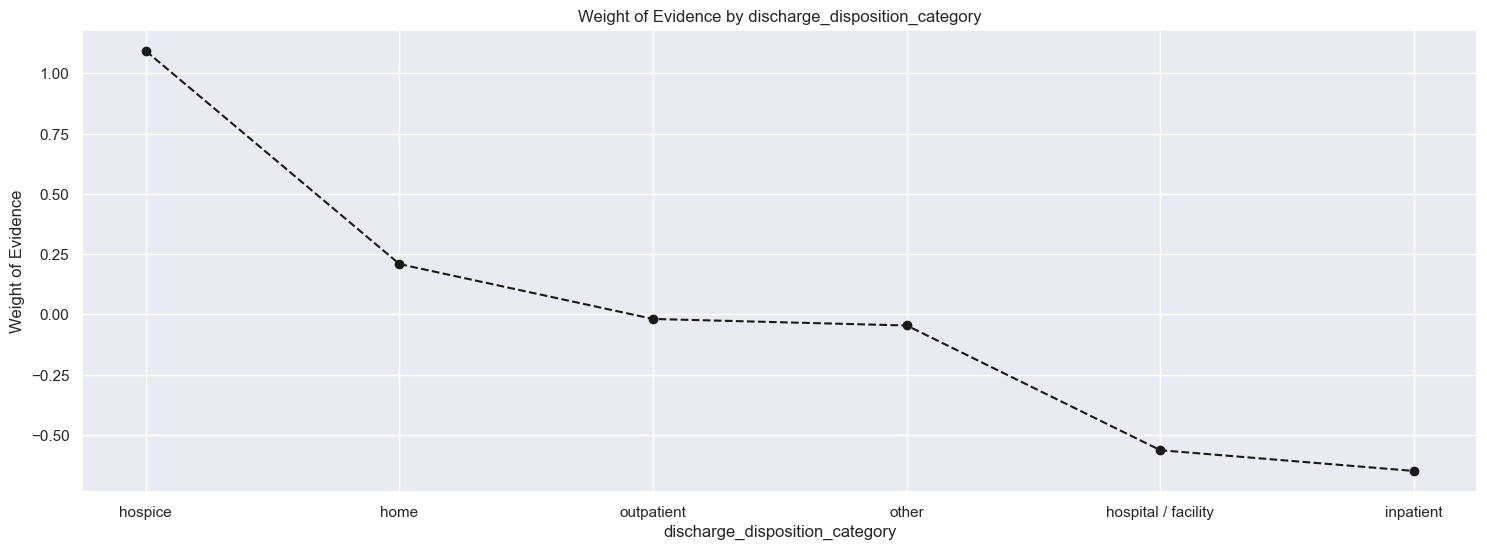

In [37]:
plot_by_woe(woe_discrete(X_train, y_train, 'discharge_disposition_category').sort_values(by = ['WoE'], ascending = False))

In [38]:
woe_map_discharge_disposition = {
    'inpatient': -0.649732,
    'hospital / facility': -0.563646,
    'other': -0.046148,
    'outpatient': -0.019023,
    'home': 0.208607,
    'hospice': 1.092834
}

In [39]:
X_train['discharge_disposition_WoE'] = X_train['discharge_disposition_category'].map(woe_map_discharge_disposition)

In [40]:
# X_train.drop(columns = ['discharge_disposition_category_inpatient', 
#                    'discharge_disposition_category_outpatient',
#                    'discharge_disposition_category_hospice',
#                    'discharge_disposition_category_other'],
#                    axis = 1, inplace = True)

# ## do the same for Test set later, exactly the same!

### diag_1, diag_2, diag_3 (decided to remove) - lack of interpretability during model training

In [41]:
# top_15_codes_diag_1 = woe_discrete(X_train, y_train, 'diag_1').sort_values(by = ['prop_total'], ascending = False).head(15)['diag_1'].values

# # Remap everything else to "Other"
# X_train['diag_1_grouped'] = X_train['diag_1'].apply(
#     lambda x: x if x in top_15_codes_diag_1 else 'Other'
# )

In [42]:
# woe_out = woe_discrete(X_train, y_train, 'diag_1_grouped')
# woe_map_diag1_grouped = dict(zip(woe_out['diag_1_grouped'], woe_out['WoE']))

# X_train['diag_1_grouped_WoE'] = X_train['diag_1_grouped'].map(woe_map_diag1_grouped)

In [43]:
# top_15_codes_diag_2 = woe_discrete(X_train, y_train, 'diag_2').sort_values(by = ['prop_total'], ascending = False).head(15)['diag_2'].values

# # Remap everything else to "Other"
# X_train['diag_2_grouped'] = X_train['diag_2'].apply(
#     lambda x: x if x in top_15_codes_diag_2 else 'Other'
# )

In [44]:
# woe_out = woe_discrete(X_train, y_train, 'diag_2_grouped')
# woe_map_diag2_grouped = dict(zip(woe_out['diag_2_grouped'], woe_out['WoE']))

# X_train['diag_2_grouped_WoE'] = X_train['diag_2_grouped'].map(woe_map_diag2_grouped)

In [45]:
# top_15_codes_diag_3 = woe_discrete(X_train, y_train, 'diag_3').sort_values(by = ['prop_total'], ascending = False).head(15)['diag_3'].values

# # Remap everything else to "Other"
# X_train['diag_3_grouped'] = X_train['diag_3'].apply(
#     lambda x: x if x in top_15_codes_diag_3 else 'Other'
# )

In [46]:
# woe_out = woe_discrete(X_train, y_train, 'diag_3_grouped')
# woe_map_diag3_grouped = dict(zip(woe_out['diag_3_grouped'], woe_out['WoE']))

# X_train['diag_3_grouped_WoE'] = X_train['diag_3_grouped'].map(woe_map_diag3_grouped)

## Numerical Variables

In [47]:
numerical_features = ['time_in_hospital', 'num_lab_procedures', 'num_procedures', 'num_medications', 'number_outpatient',
                      'number_emergency', 'number_inpatient', 'number_diagnoses', 'total_procedures', 'lab_med_ratio']

In [48]:
iv_dict = {}

for col in numerical_features:
    binned = col
    if X_train[col].nunique() > 15:
        binned = f"{col}_bin"
        X_train[binned] = pd.qcut(X_train[col], q=10, duplicates='drop')
    result = woe_discrete(X_train, y_train, binned)  # ✅ only pass the column name
    iv_dict[col] = result['IV'].iloc[0]

# sort and display
iv_dict = dict(sorted(iv_dict.items(), key=lambda x: x[1], reverse=True))
for k, v in iv_dict.items():
    print(f"{k}: {v:.4f}")

number_inpatient: 0.0883
time_in_hospital: 0.0453
num_medications: 0.0263
number_diagnoses: 0.0219
total_procedures: 0.0212
lab_med_ratio: 0.0159
num_lab_procedures: 0.0144
num_procedures: 0.0022
number_outpatient: 0.0008
number_emergency: 0.0000


In [49]:
X_train.drop(columns = ['lab_med_ratio_bin', 
                        'num_lab_procedures',
                        'num_procedures',
                        'number_outpatient_bin',
                        'number_emergency_bin'],axis = 1, inplace = True )             

### Number of inpatient

In [50]:
woe_discrete(X_train, y_train, 'number_inpatient')

,number_inpatient,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0.0,43595,0.080858,0.919142,3525.0,40070.0,0.800227,0.892507,0.109139,0.092280,0.088334,0.884262
1,1.0,4006,0.126560,0.873440,507.0,3499.0,0.115096,0.077936,-0.389887,-0.037161,0.088334,0.081256
2,2.0,1060,0.188679,0.811321,200.0,860.0,0.045403,0.019155,-0.862993,-0.026248,0.088334,0.021501
3,3.0,329,0.237082,0.762918,78.0,251.0,0.017707,0.005591,-1.152864,-0.012116,0.088334,0.006673
4,4.0,167,0.257485,0.742515,43.0,124.0,0.009762,0.002762,-1.262527,-0.007000,0.088334,0.003387
5,5.0,77,0.311688,0.688312,24.0,53.0,0.005448,0.001181,-1.529370,-0.004268,0.088334,0.001562
6,6.0,35,0.400000,0.600000,14.0,21.0,0.003178,0.000468,-1.916143,-0.002710,0.088334,0.000710
7,7.0,15,0.600000,0.400000,9.0,6.0,0.002043,0.000134,-2.727073,-0.001909,0.088334,0.000304
8,8.0,9,0.222222,0.777778,2.0,7.0,0.000454,0.000156,-1.068845,-0.000298,0.088334,0.000183
9,9.0,6,0.333333,0.666667,2.0,4.0,0.000454,0.000089,-1.628460,-0.000365,0.088334,0.000122


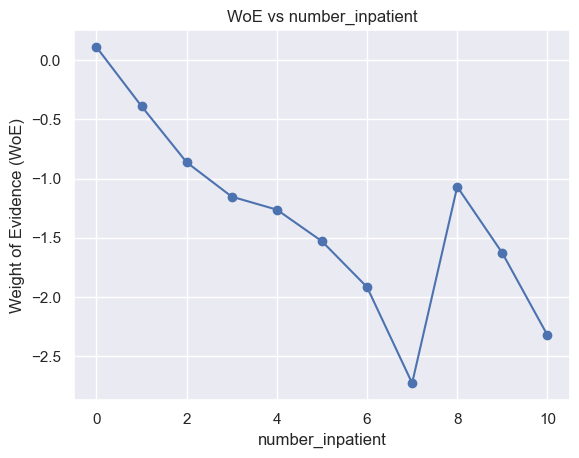

In [51]:
result = woe_discrete(X_train, y_train, 'number_inpatient')

result_sorted = result.copy()
result_sorted['number_inpatient'] = result_sorted['number_inpatient'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient')

plt.plot(result_sorted['number_inpatient'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

In [52]:
X_train['number_inpatient'] = X_train['number_inpatient'].clip(upper=7)

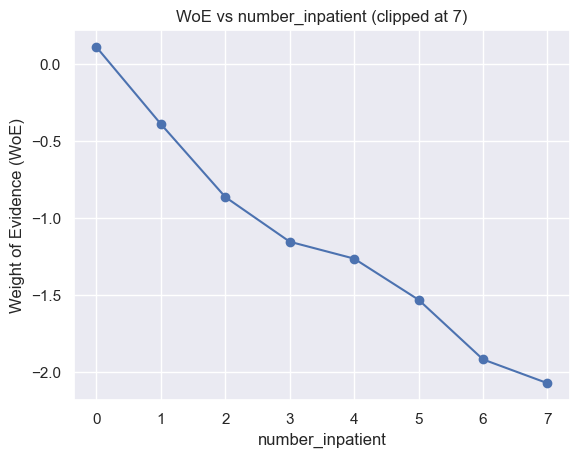

In [53]:
result = woe_discrete(X_train, y_train, 'number_inpatient')

result_sorted = result.copy()
result_sorted['number_inpatient'] = result_sorted['number_inpatient'].astype(float)
result_sorted = result_sorted.sort_values('number_inpatient')

plt.plot(result_sorted['number_inpatient'], result_sorted['WoE'], marker='o')
plt.xlabel('number_inpatient')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_inpatient (clipped at 7)')
plt.show()  

## can see that 8,9,10 show volatile. This is due to small sample that caused the random noise!! 

### Time in Hospital

In [54]:
woe_discrete(X_train, y_train, 'time_in_hospital')

,time_in_hospital,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1.0,7356,0.067156,0.932844,494.0,6862.0,0.112145,0.152842,0.309610,0.040697,0.045321,0.149206
1,2.0,8583,0.075032,0.924968,644.0,7939.0,0.146198,0.176831,0.190235,0.030633,0.045321,0.174094
2,3.0,8673,0.082209,0.917791,713.0,7960.0,0.161862,0.177299,0.091094,0.015437,0.045321,0.175919
3,4.0,6580,0.087842,0.912158,578.0,6002.0,0.131215,0.133687,0.018666,0.002472,0.045321,0.133466
4,5.0,4755,0.098002,0.901998,466.0,4289.0,0.105789,0.095532,-0.101985,-0.010257,0.045321,0.096448
5,6.0,3565,0.107714,0.892286,384.0,3181.0,0.087174,0.070853,-0.207300,-0.016321,0.045321,0.072311
6,7.0,2770,0.105415,0.894585,292.0,2478.0,0.066288,0.055194,-0.183155,-0.011094,0.045321,0.056185
7,8.0,2047,0.125550,0.874450,257.0,1790.0,0.058343,0.039870,-0.380714,-0.018473,0.045321,0.041520
8,9.0,1353,0.127864,0.872136,173.0,1180.0,0.039274,0.026283,-0.401630,-0.012991,0.045321,0.027444
9,10.0,1073,0.123952,0.876048,133.0,940.0,0.030193,0.020937,-0.366078,-0.009256,0.045321,0.021764


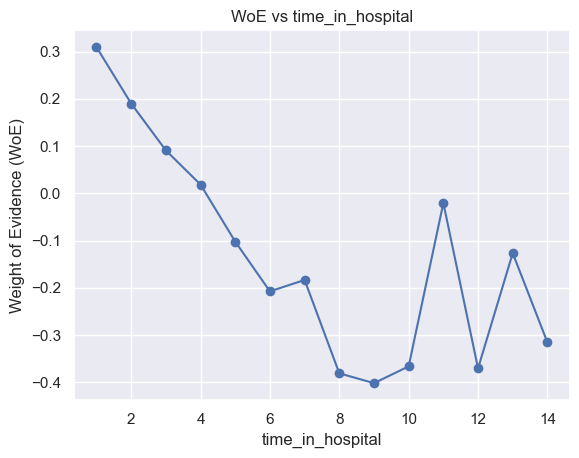

In [55]:
result = woe_discrete(X_train, y_train, 'time_in_hospital')

result_sorted = result.copy()
result_sorted['time_in_hospital'] = result_sorted['time_in_hospital'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital')

plt.plot(result_sorted['time_in_hospital'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital')
plt.show()  

In [56]:
def bin_time_in_hospital(x):
    if x >= 8:
        return 8      # small sample population from 8 onwards! should combine and clip to 8 max.
    else:
        return x

X_train['time_in_hospital'] = X_train['time_in_hospital'].apply(bin_time_in_hospital)

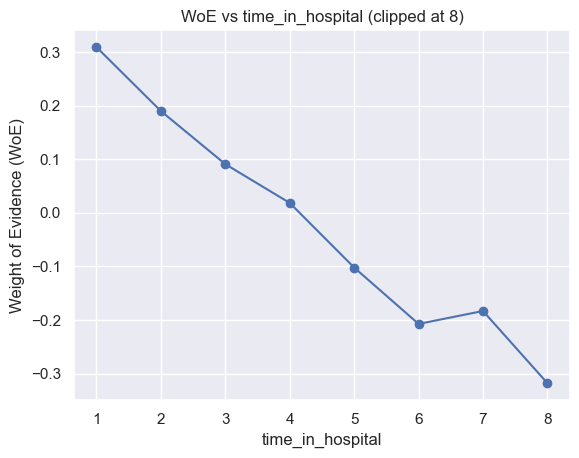

In [57]:
result = woe_discrete(X_train, y_train, 'time_in_hospital')

result_sorted = result.copy()
result_sorted['time_in_hospital'] = result_sorted['time_in_hospital'].astype(float)
result_sorted = result_sorted.sort_values('time_in_hospital')

plt.plot(result_sorted['time_in_hospital'], result_sorted['WoE'], marker='o')
plt.xlabel('time_in_hospital')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs time_in_hospital (clipped at 8)')
plt.show()  

### Number of Diagnoses

In [58]:
woe_discrete(X_train, y_train, 'number_diagnoses')

,number_diagnoses,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,1.0,131,0.022901,0.977099,3.0,128.0,0.000681,0.002851,1.431809,0.002170,0.029337,0.002657
1,2.0,597,0.050251,0.949749,30.0,567.0,0.006810,0.012629,0.617553,0.005819,0.029337,0.012109
2,3.0,1623,0.058534,0.941466,95.0,1528.0,0.021566,0.034034,0.456230,0.012468,0.029337,0.032920
3,4.0,3078,0.071150,0.928850,219.0,2859.0,0.049716,0.063681,0.247547,0.013964,0.029337,0.062433
4,5.0,6304,0.077253,0.922747,487.0,5817.0,0.110556,0.129566,0.158667,0.019010,0.029337,0.127868
5,6.0,5312,0.085655,0.914345,455.0,4857.0,0.103292,0.108183,0.046270,0.004892,0.029337,0.107746
6,7.0,5244,0.088863,0.911137,466.0,4778.0,0.105789,0.106424,0.005983,0.000635,0.029337,0.106367
7,8.0,5167,0.096187,0.903813,497.0,4670.0,0.112826,0.104018,-0.081284,-0.008808,0.029337,0.104805
8,9.0,21792,0.098522,0.901478,2147.0,19645.0,0.487401,0.437567,-0.107857,-0.049834,0.029337,0.442019
9,10.0,6,0.166667,0.833333,1.0,5.0,0.000227,0.000111,-0.712170,-0.000116,0.029337,0.000122


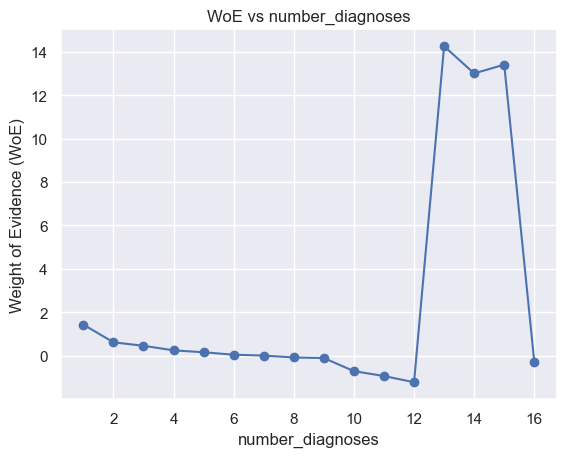

In [59]:
result = woe_discrete(X_train, y_train, 'number_diagnoses')

result_sorted = result.copy()
result_sorted['number_diagnoses'] = result_sorted['number_diagnoses'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses')

plt.plot(result_sorted['number_diagnoses'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses')
plt.show()   # SMALL SAMPLE SIZE from 10 onwards, random noise!!!!!

In [60]:
X_train['number_diagnoses'] = np.where(X_train['number_diagnoses'] >= 10, 10, X_train['number_diagnoses'])

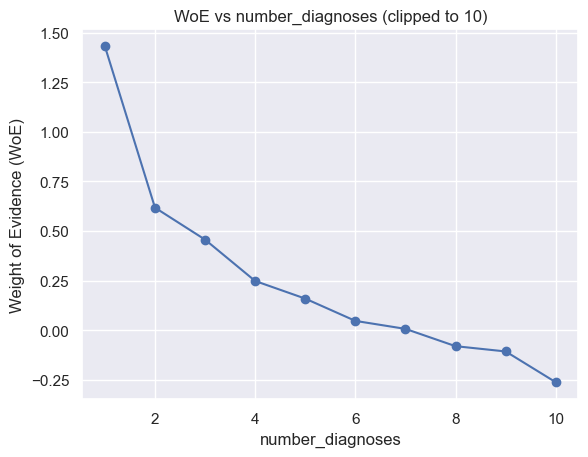

In [61]:
result = woe_discrete(X_train, y_train, 'number_diagnoses')

result_sorted = result.copy()
result_sorted['number_diagnoses'] = result_sorted['number_diagnoses'].astype(float)
result_sorted = result_sorted.sort_values('number_diagnoses')

plt.plot(result_sorted['number_diagnoses'], result_sorted['WoE'], marker='o')
plt.xlabel('number_diagnoses')
plt.ylabel('Weight of Evidence (WoE)')
plt.title('WoE vs number_diagnoses (clipped to 10)')
plt.show()  

### Total number of procedures

In [62]:
woe_discrete(X_train, y_train, 'total_procedures_bin')

,total_procedures_bin,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,"(1.999, 27.0]",4964,0.070105,0.929895,348.0,4616.0,0.079001,0.102815,0.263473,0.023814,0.021172,0.100688
1,"(27.0, 41.0]",5275,0.078483,0.921517,414.0,4861.0,0.093984,0.108272,0.141525,0.014288,0.021172,0.106996
2,"(41.0, 49.0]",5290,0.080718,0.919282,427.0,4863.0,0.096935,0.108317,0.111018,0.011382,0.021172,0.107300
3,"(49.0, 54.0]",4211,0.081691,0.918309,344.0,3867.0,0.078093,0.086132,0.097984,0.008039,0.021172,0.085414
4,"(54.0, 60.0]",5285,0.085147,0.914853,450.0,4835.0,0.102157,0.107693,0.052780,0.005537,0.021172,0.107199
5,"(60.0, 66.0]",5251,0.092744,0.907256,487.0,4764.0,0.110556,0.106112,-0.041030,-0.004444,0.021172,0.106509
6,"(66.0, 72.0]",4820,0.091286,0.908714,440.0,4380.0,0.099886,0.097559,-0.023579,-0.002328,0.021172,0.097767
7,"(72.0, 79.0]",4622,0.102986,0.897014,476.0,4146.0,0.108059,0.092347,-0.157127,-0.015712,0.021172,0.093751
8,"(79.0, 90.0]",4940,0.106275,0.893725,525.0,4415.0,0.119183,0.098338,-0.192244,-0.020844,0.021172,0.100201
9,"(90.0, 170.0]",4643,0.106397,0.893603,494.0,4149.0,0.112145,0.092414,-0.193521,-0.019732,0.021172,0.094177


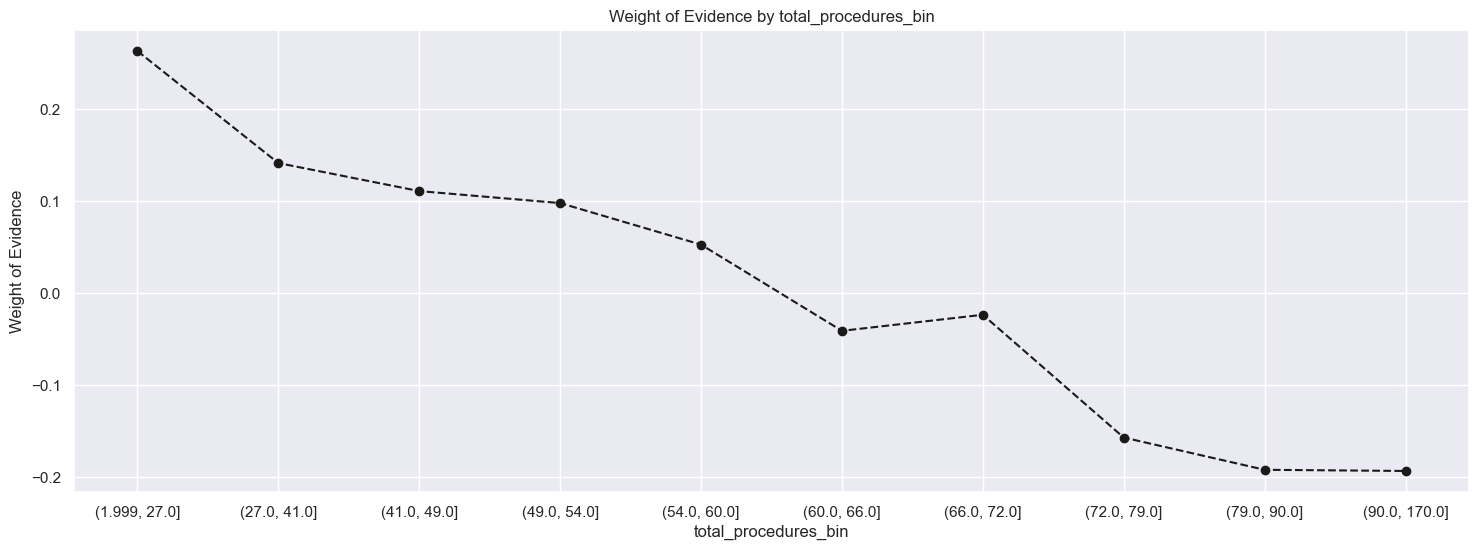

In [63]:
plot_by_woe(woe_discrete(X_train, y_train, 'total_procedures_bin'))

### Exploring more variables outside of IV < 0.02, but hold certain relationship

#### Insulin Change

<Axes: xlabel='insulin'>

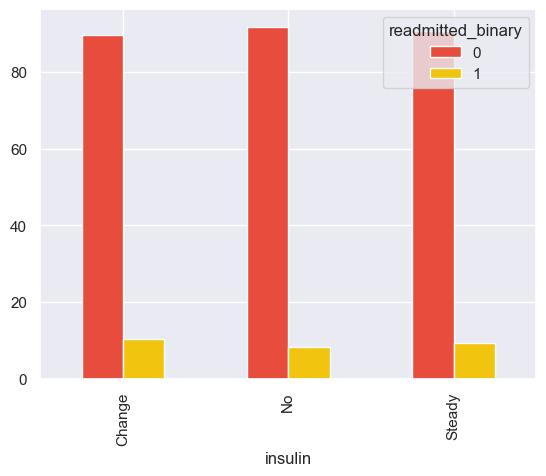

In [64]:
colors = ['#E74C3C','#F1C40F','#2ECC71']
readmit_race = pd.crosstab(X_train['insulin'], y_train, normalize='index') * 100
readmit_race.plot(kind='bar', stacked=False, color = colors)

In [65]:
### seems like not strictly ordinal, one-hot encode instead.

X_train = pd.get_dummies(X_train, columns=['insulin'], drop_first=True)

### Total number of emergency

In [66]:
X_train_1 = pd.concat([X_train, y_train], axis = 1)

<Axes: xlabel='readmitted_binary'>

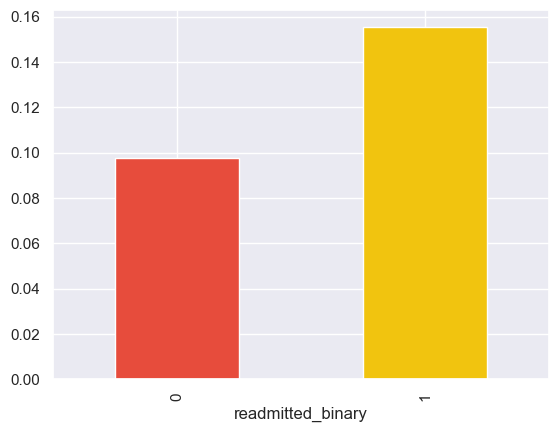

In [67]:
readmit_visits = X_train_1.groupby('readmitted_binary')['number_emergency'].mean()
readmit_visits.plot(kind='bar', color = colors)

In [68]:
pd.set_option("display.max_rows", 20)

In [69]:
woe_discrete(X_train, y_train, 'number_emergency')

,number_emergency,n_obs,prop_bad,prop_good,n_bad,n_good,prop_n_bad,prop_n_good,WoE,%Good - %Bad,IV,prop_total
0,0.0,45744,0.086591,0.913409,3961.0,41783.0,0.899205,0.930662,0.034385,0.031457,0.024596,0.927851
1,1.0,2697,0.119763,0.880237,323.0,2374.0,0.073326,0.052878,-0.326929,-0.020448,0.024596,0.054705
2,2.0,557,0.123878,0.876122,69.0,488.0,0.015664,0.010870,-0.365400,-0.004794,0.024596,0.011298
3,3.0,176,0.125000,0.875000,22.0,154.0,0.004994,0.003430,-0.375698,-0.001564,0.024596,0.003570
4,4.0,66,0.257576,0.742424,17.0,49.0,0.003859,0.001091,-1.263001,-0.002768,0.024596,0.001339
5,5.0,20,0.200000,0.800000,4.0,16.0,0.000908,0.000356,-0.935314,-0.000552,0.024596,0.000406
6,6.0,19,0.210526,0.789474,4.0,15.0,0.000908,0.000334,-0.999852,-0.000574,0.024596,0.000385
7,7.0,6,0.166667,0.833333,1.0,5.0,0.000227,0.000111,-0.712170,-0.000116,0.024596,0.000122
8,8.0,6,0.333333,0.666667,2.0,4.0,0.000454,0.000089,-1.628460,-0.000365,0.024596,0.000122
9,9.0,1,0.000000,1.000000,0.0,1.0,0.000000,0.000022,12.313751,0.000022,0.024596,0.000020


In [70]:
X_train['number_emergency'] = np.where(X_train['number_emergency'] >= 4, 4, X_train['number_emergency'])

### Final X_Train

In [71]:
pd.set_option("display.max_rows", 50)

In [72]:
chosen = ['age_encoded', 'discharge_disposition_WoE', 
          'number_inpatient', 'time_in_hospital', 'number_diagnoses', 'total_procedures_bin', 'number_emergency', 'insulin_No', 'insulin_Steady']

In [73]:
X_train = X_train[chosen]

In [74]:
X_train['total_procedures_ord'] = X_train['total_procedures_bin'].cat.codes

#### Apply same transformation of Training onto Test

In [75]:
# Apply same transformation of Training onto Test

In [76]:
age_order = [
    '[0-10)', '[10-20)', '[20-30)', '[30-40)', '[40-50)',
    '[50-60)', '[60-70)', '[70-80)', '[80-90)', '[90-100)'
]

# Create a mapping dictionary: bin → ordinal number
age_mapping = {age: i+1 for i, age in enumerate(age_order)}

# Apply the mapping
X_test['age_encoded'] = X_test['age'].map(age_mapping)

In [77]:
X_test['discharge_disposition_WoE'] = X_test['discharge_disposition_category'].map(woe_map_discharge_disposition)

In [78]:
X_test['number_inpatient'] = X_test['number_inpatient'].clip(upper=7)

In [79]:
X_test['time_in_hospital'] = X_test['time_in_hospital'].clip(upper=8)

In [80]:
X_test['number_diagnoses'] = X_test['number_diagnoses'].clip(upper=10)

In [81]:
bins = [i.left for i in X_train['total_procedures_bin'].cat.categories] + [X_train['total_procedures_bin'].cat.categories[-1].right]
X_test['total_procedures_bin'] = pd.cut(X_test['total_procedures'], bins=bins, include_lowest=True)
X_test['total_procedures_ord'] = X_test['total_procedures_bin'].cat.codes

In [82]:
X_test['number_emergency'] = np.where(X_test['number_emergency'] >= 4, 4, X_test['number_emergency'])

In [83]:
### seems like not strictly ordinal, one-hot encode instead.

X_test = pd.get_dummies(X_test, columns=['insulin'], drop_first=True)

In [84]:
# # Remap everything else to "Other"
# X_test['diag_1_grouped'] = X_test['diag_1'].apply(
#     lambda x: x if x in top_15_codes_diag_1 else 'Other'
# )

# X_test['diag_2_grouped'] = X_test['diag_2'].apply(
#     lambda x: x if x in top_15_codes_diag_1 else 'Other'
# )

# X_test['diag_3_grouped'] = X_test['diag_3'].apply(
#     lambda x: x if x in top_15_codes_diag_1 else 'Other'
# )

# X_test['diag_1_grouped_WoE'] = X_test['diag_1_grouped'].map(woe_map_diag1_grouped)
# X_test['diag_2_grouped_WoE'] = X_test['diag_2_grouped'].map(woe_map_diag2_grouped)
# X_test['diag_3_grouped_WoE'] = X_test['diag_3_grouped'].map(woe_map_diag3_grouped)

In [85]:
X_train.drop(columns = ['total_procedures_bin'], axis = 1, inplace = True)

In [86]:
X_train

,age_encoded,discharge_disposition_WoE,number_inpatient,time_in_hospital,number_diagnoses,number_emergency,insulin_No,insulin_Steady,total_procedures_ord
15796,8,-0.046148,0,2,8,0,True,False,4
91253,4,0.208607,0,2,3,0,False,True,5
3377,8,-0.563646,0,5,9,0,False,False,7
16822,7,-0.046148,0,8,7,0,True,False,9
57752,7,0.208607,0,3,6,0,True,False,5
...,...,...,...,...,...,...,...,...,...
819,5,0.208607,0,2,3,0,False,False,3
31852,5,0.208607,0,5,5,0,False,True,7
92538,7,0.208607,0,8,9,0,False,False,9
45895,8,0.208607,0,1,9,0,True,False,1


In [87]:
X_test = X_test[['age_encoded', 'discharge_disposition_WoE', 
          'number_inpatient', 'time_in_hospital', 'number_diagnoses', 'number_emergency', 'insulin_No', 'insulin_Steady', 'total_procedures_ord']]

In [88]:
X_test

,age_encoded,discharge_disposition_WoE,number_inpatient,time_in_hospital,number_diagnoses,number_emergency,insulin_No,insulin_Steady,total_procedures_ord
49482,8,0.208607,0,3,9,0,False,True,3
65380,10,0.208607,0,3,9,0,False,True,0
74422,10,-0.563646,0,7,9,0,True,False,5
15331,10,-0.649732,0,3,7,0,False,True,7
23295,6,0.208607,0,3,6,0,False,True,7
...,...,...,...,...,...,...,...,...,...
7248,6,0.208607,0,8,9,0,True,False,4
81289,8,0.208607,1,2,4,0,True,False,4
49094,7,0.208607,0,5,9,0,False,True,1
35252,7,0.208607,0,5,9,0,True,False,8


In [89]:
X_train = X_train.astype({col: int for col in X_train.select_dtypes(bool).columns})
X_test  = X_test.astype({col: int for col in X_test.select_dtypes(bool).columns})

In [90]:
pd.set_option("display.max_rows", 30)

In [91]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

In [92]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49291
Method:                           MLE   Df Model:                            9
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03282
Time:                        15:18:07   Log-Likelihood:                -14354.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                6.173e-204
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.9512      0.099    -29.712      0.000      -3.146      -2.757
age_encoded                   0.0404      0.011      3.646      0.000       0.019     

#### Drop the highly statistically insignificant 'total_procedures_ord' variable

In [93]:
X_train.drop(['total_procedures_ord'], axis = 1, inplace = True)
X_test.drop(['total_procedures_ord'], axis = 1, inplace = True)

In [94]:
import statsmodels.api as sm

X_train_const = sm.add_constant(X_train)
X_test_const  = sm.add_constant(X_test)

logit_model = sm.Logit(y_train, X_train_const)
result = logit_model.fit(disp=False)

## Final Model

In [95]:
print(result.summary())

                           Logit Regression Results                           
Dep. Variable:      readmitted_binary   No. Observations:                49301
Model:                          Logit   Df Residuals:                    49292
Method:                           MLE   Df Model:                            8
Date:                Sun, 19 Oct 2025   Pseudo R-squ.:                 0.03274
Time:                        15:18:07   Log-Likelihood:                -14355.
converged:                       True   LL-Null:                       -14841.
Covariance Type:            nonrobust   LLR p-value:                1.820e-204
                                coef    std err          z      P>|z|      [0.025      0.975]
---------------------------------------------------------------------------------------------
const                        -2.9309      0.098    -29.774      0.000      -3.124      -2.738
age_encoded                   0.0396      0.011      3.585      0.000       0.018     

In [96]:
y_pred_prob = result.predict(X_train_const)

In [97]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Training AUC:", roc_auc_score(y_train, y_pred_prob))

Training AUC: 0.6382002588097664


In [98]:
y_pred_prob = result.predict(X_test_const)

In [99]:
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, roc_curve

print("Testing AUC:", roc_auc_score(y_test, y_pred_prob))

Testing AUC: 0.637971506208171


In [100]:
from statsmodels.stats.outliers_influence import variance_inflation_factor
vif = pd.DataFrame()
vif["VIF"] = [variance_inflation_factor(X_train_const.values, i)
              for i in range(X_train_const.shape[1])]
vif["variable"] = X_train_const.columns
print(vif)

         VIF                   variable
0  33.709171                      const
1   1.148110                age_encoded
2   1.093118  discharge_disposition_WoE
3   1.031597           number_inpatient
4   1.123208           time_in_hospital
5   1.137049           number_diagnoses
6   1.034199           number_emergency
7   1.835055                 insulin_No
8   1.781828             insulin_Steady


In [101]:
import numpy as np
from sklearn.metrics import precision_recall_curve, f1_score

# y_pred_prob is from statsmodels
print(np.quantile(y_pred_prob, [0, 0.25, 0.5, 0.75, 0.9, 0.99]))
# just to see the probability range — usually all below 0.5 for imbalanced data

# compute precision, recall, thresholds
prec, rec, thr = precision_recall_curve(y_test, y_pred_prob, pos_label=1)

# compute F1 for each threshold (align properly)
f1 = 2 * prec[1:] * rec[1:] / (prec[1:] + rec[1:] + 1e-12)

best_idx = np.nanargmax(f1)
best_thr = thr[best_idx]

print("Best F1:", f1[best_idx])
print("Best threshold:", best_thr)


[0.02816572 0.06253805 0.07247498 0.10174794 0.14432551 0.24736187]
Best F1: 0.22878228782250443
Best threshold: 0.09574639011348975


In [102]:
y_pred = (y_pred_prob >= 0.09574639011348975).astype(int)

In [103]:
from sklearn.metrics import confusion_matrix

print(confusion_matrix(y_test, y_pred))

[[14404  4838]
 [ 1020   868]]


In [104]:
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Classification Report:
               precision    recall  f1-score   support

           0       0.93      0.75      0.83     19242
           1       0.15      0.46      0.23      1888

    accuracy                           0.72     21130
   macro avg       0.54      0.60      0.53     21130
weighted avg       0.86      0.72      0.78     21130



### Experimentation - Making use of Scikit-Learn Regression package to handle class imbalance after selecting final features from StatsModel

In [105]:
from sklearn.linear_model import LogisticRegression

In [106]:
model = LogisticRegression(class_weight='balanced', max_iter=1000, random_state=42)
model.fit(X_train, y_train)

# ============================================
# 📊 Evaluate Performance
# ============================================
y_pred = model.predict(X_test)
y_pred_proba = model.predict_proba(X_test)[:, 1]

# Metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_proba)

# Print results
print("Model Performance Metrics:")
print(f"Accuracy : {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall   : {recall:.4f}")
print(f"F1-Score : {f1:.4f}")
print(f"ROC-AUC  : {roc_auc:.4f}\n")

print("Classification Report:")
print(classification_report(y_test, y_pred, digits=4))

Model Performance Metrics:
Accuracy : 0.6916
Precision: 0.1446
Recall   : 0.4989
F1-Score : 0.2243
ROC-AUC  : 0.6383

Classification Report:
              precision    recall  f1-score   support

           0     0.9353    0.7105    0.8075     19242
           1     0.1446    0.4989    0.2243      1888

    accuracy                         0.6916     21130
   macro avg     0.5400    0.6047    0.5159     21130
weighted avg     0.8646    0.6916    0.7554     21130



In [108]:
# Compute confusion matrix
cm = confusion_matrix(y_test, y_pred)

# Extract values
tn, fp, fn, tp = cm.ravel()

print("Confusion Matrix:")
print(cm)
print(f"\nTrue Negatives (TN): {tn}")
print(f"False Positives (FP): {fp}")
print(f"False Negatives (FN): {fn}")
print(f"True Positives (TP): {tp}")

Confusion Matrix:
[[13671  5571]
 [  946   942]]

True Negatives (TN): 13671
False Positives (FP): 5571
False Negatives (FN): 946
True Positives (TP): 942
